## Part (2)(a) Derivation:

### Starting from the given discretized form of the anisotropic diffusion equation:

### $-\mu_x \frac{u_{i-1,j} - 2u_{i,j} + u_{i+1,j}}{h^2} - \mu_y \frac{u_{i,j-1} - 2u_{i,j} + u_{i,j+1}}{h^2} = f_{i,j}$

### Rearrange terms to isolate the $u$-values:

### $-\left(\frac{\mu_x}{h^2}\right) \left(u_{i+1,j} - 2u_{i,j} + u_{i-1,j}\right) - \left(\frac{\mu_y}{h^2}\right) \left(u_{i,j+1} - 2u_{i,j} + u_{i,j-1}\right) = f_{i,j}$

### Distribute the factors:

### From the $x$-direction:  
### $-\frac{\mu_x}{h^2}(u_{i+1,j}) + \frac{2\mu_x}{h^2}(u_{i,j}) - \frac{\mu_x}{h^2}(u_{i-1,j})$

### From the $y$-direction:  
### $-\frac{\mu_y}{h^2}(u_{i,j+1}) + \frac{2\mu_y}{h^2}(u_{i,j}) - \frac{\mu_y}{h^2}(u_{i,j-1})$

### Combine like terms for $u_{i,j}$:

### $\left(\frac{2\mu_x}{h^2} + \frac{2\mu_y}{h^2}\right)u_{i,j} - \frac{\mu_x}{h^2}u_{i+1,j} - \frac{\mu_x}{h^2}u_{i-1,j} - \frac{\mu_y}{h^2}u_{i,j+1} - \frac{\mu_y}{h^2}u_{i,j-1} = f_{i,j}$

#### Notice that the coefficients for the diagonal neighbors $u_{i\pm1,j\pm1}$ are zero; hence, the stencil involves only the direct neighbors in the horizontal and vertical directions.

---

## Stencil Form:

### Indexing the stencil as $3 \times 3$:

### $S = 
\begin{bmatrix}
s_{11} & s_{12} & s_{13} \\
s_{21} & s_{22} & s_{23} \\
s_{31} & s_{32} & s_{33}
 \end{bmatrix}$

#### where:  
### - $s_{22}$ corresponds to $u_{i,j}$  
### - $s_{12}$ to $u_{i,j+1}$  
### - $s_{32}$ to $u_{i,j-1}$  
### - $s_{21}$ to $u_{i-1,j}$  
### - $s_{23}$ to $u_{i+1,j}$  

#### All corner points $(i \pm 1, j \pm 1)$ have zero coefficients because the equation does not directly couple diagonals.

#### Thus:

### - $s_{22} = \frac{2(\mu_x + \mu_y)}{h^2}$ (center)  
### - $s_{21} = -\frac{\mu_x}{h^2}$ (left neighbor)  
### - $s_{23} = -\frac{\mu_x}{h^2}$ (right neighbor)  
### - $s_{12} = -\frac{\mu_y}{h^2}$ (top neighbor)  
### - $s_{32} = -\frac{\mu_y}{h^2}$ (bottom neighbor)  

#### All diagonal terms $s_{11}, s_{13}, s_{31}, s_{33}$ are zero.

---

## Final Stencil:

# $S = 
\begin{bmatrix}
0 & -\frac{\mu_y}{h^2} & 0 \\
-\frac{\mu_x}{h^2} & \frac{2(\mu_x + \mu_y)}{h^2} & -\frac{\mu_x}{h^2} \\
0 & -\frac{\mu_y}{h^2} & 0
\end{bmatrix}$

---

### Part (2)(b) Modification to include anisotropic diffusion coefficients $\mu_x$ and $\mu_y$
 
In the original discretization of the Laplacian operator in UNIT 18, we assumed isotropic diffusion, meaning the diffusion coefficient was the same in both $x$ and $y$ directions. In part (b), we changed this assumption by introducing two separate positive constants $\mu_x > 0$ and $\mu_y > 0$. These represent the diffusion rates in the $x$- and $y$-directions, respectively.

We modified the finite difference stencil for the second derivatives:

### $u_{xx} \approx \frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{h^2}, \quad u_{yy} \approx \frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{h^2}$.

The anisotropic diffusion equation is:

### $-\left(\mu_x u_{xx} + \mu_y u_{yy}\right) = f(x, y)$.

When discretized, each internal node $(i,j)$ receives contributions from its neighbors in the $x$ and $y$ directions, weighted by $\mu_x$ and $\mu_y$. The resulting stencil coefficients for the matrix $A$ are:

##### - **Center:** $\frac{2(\mu_x + \mu_y)}{h^2}$  
##### - **Left/Right neighbors:** $-\frac{\mu_x}{h^2}$  
##### - **Up/Down neighbors:** $-\frac{\mu_y}{h^2}$  

This modification was implemented in the `laplacianMatrix(mu_x, mu_y, n)` function. Now the solver can handle anisotropic problems, meaning it can represent scenarios where diffusion is stronger in one direction than the other.

**Conclusion for (b):**  
I extended our solver from isotropic to anisotropic diffusion by adjusting the finite difference matrix assembly. This sets the stage for exploring how anisotropy affects the solution and solver behavior.

---

In [14]:
import numpy as np
import scipy as sp
import math
from scipy.sparse.linalg import norm
from scipy.sparse.linalg import cg
from matplotlib import pyplot as plt

In [23]:
def myNewtonSys(fnon, jac, x0, tol, maxk, *fnonargs):
    # fnon     - name of the nonlinear function f(x)
    # jac      - name of the Jacobian function J(x)
    # x0       - initial guess for the solution x0
    # tol      - stopping tolerance for Newton's iteration
    # maxk     - maximum number of Newton iterations before stopping
    # fnonargs - optional arguments that will be passed to the nonlinear function (useful for additional function parameters)
    
    k = 0
    x = x0.copy()

    if sp.sparse.issparse(x):
        x = x.toarray()

    F = fnon(x,*fnonargs)
    normF = (F.data**2).sum()

    print(' k    f(xk)')
    while (normF > tol and k <= maxk):
        F0 = F
        J = jac(x,F.shape[0],fnon,F0,*fnonargs)
        delta = np.linalg.solve(J.toarray(), F.toarray())
        x = x - delta
        F = fnon(x,*fnonargs)
        normF = (F.data**2).sum()
        print('{0:2d}  {1:2.2e}'.format(k, normF))
        k += 1

    if k > maxk:
        print('Not converged')
    return x  

In [24]:
def laplacianMatrix(mu_x, mu_y, n):
    N = n**2
    A = sp.sparse.lil_array((N, N), dtype=np.float64)
    h = 1.0/(n-1)

    # Stencil coefficients:
    # center: 2*(mu_x+mu_y)/h^2
    # left: -mu_x/h^2
    # right: -mu_x/h^2
    # up: -mu_y/h^2
    # down: -mu_y/h^2
    for i in range(1,n-1):
        for j in range(1,n-1):
            row = indexFD(i,j,n)
            A[row, row] = 2*(mu_x+mu_y)/h**2
            A[row, indexFD(i-1,j,n)] = -mu_x/h**2
            A[row, indexFD(i+1,j,n)] = -mu_x/h**2
            A[row, indexFD(i,j-1,n)] = -mu_y/h**2
            A[row, indexFD(i,j+1,n)] = -mu_y/h**2

    return A.tocsc()

In [25]:
def indexFD(i, j, n):
    return i*n + j

def boundaryConditions(n):
    extNodes = []
    for j in range(n):
        extNodes.append(indexFD(j,0,n))
        extNodes.append(indexFD(j,n-1,n))
        extNodes.append(indexFD(0,j,n))
        extNodes.append(indexFD(n-1,j,n))
    extNodes = np.unique(extNodes)
    intNodes = np.setdiff1d(np.arange(n**2), extNodes)
    return intNodes, extNodes

def getNeighbours(k, n):
    i = k//n
    j = k%n
    neighs = [k]
    if i>0: neighs.append(indexFD(i-1,j,n))
    if i<n-1: neighs.append(indexFD(i+1,j,n))
    if j>0: neighs.append(indexFD(i,j-1,n))
    if j<n-1: neighs.append(indexFD(i,j+1,n))
    return neighs

In [26]:
def fdJacobian(x,N,fnon,F0,*fnonargs):
    J = sp.sparse.lil_array((N,N), dtype=np.float64)
    h = 1e-8
    n = int(math.sqrt(N))

    # Finite difference approximation for each column
    for k in range(N):
        xb = x.copy()
        xb[k,0] += h
        F = fnon(xb,*fnonargs)
        neighs = getNeighbours(k,n)
        for i in neighs:
            J[i,k] = (F[i,0]-F0[i,0])/h

    return J.tocsc()

---
### Part (2)(c) Implementation of a spatially varying right-hand side $f(x, y)$

Instead of a constant or zero source term, we introduced a source function that is equal to 1 inside a subregion $[0.1, 0.3] \times [0.1, 0.3]$ of the unit square, and 0 elsewhere. This models a localized heat source within the computational domain. Thus, $f(x, y)$ is defined as:

$
f(x, y) =
\begin{cases} 
1 & \text{if } 0.1 \leq x \leq 0.3 \text{ and } 0.1 \leq y \leq 0.3, \\ 
0 & \text{otherwise.}
\end{cases}
$

**Implementation:**  
1. I wrote a function `source_function(k, n)` that uses the index $k$ to find the coordinates $(x, y)$ on the grid, and returns 1 if $(x, y)$ is inside the source region, and 0 otherwise.  
2. In `laplaceF(u, A, n)`, I replaced the previous handling of the right-hand side with calls to `source_function`. Thus, the internal nodes now have a forcing term corresponding to the localized source.

**Result:**  
##### The PDE we are solving is now:

#### $-\left(\mu_x u_{xx} + \mu_y u_{yy}\right) = f(x, y),$

with $f(x, y)$ as defined above, and $u = 0$ on the boundary.

This creates a solution with a **“peak”** in the region where the source is active, and zero at the boundary. This significantly affects the shape of the solution: the output is shown as a bump in the $[0.1, 0.3]^2$ area and a smooth decay to zero as we move away from this region. 

---

In [30]:
def laplaceF(u, A, n):
    N = n**2
    
    f = sp.sparse.lil_array((N,1), dtype=np.float64)

    intNodes, extNodes = boundaryConditions(n)
    Au = A[intNodes,:] @ u
    Fu = sp.sparse.lil_array((N,1), dtype=np.float64)

    # Evaluate source function on internal nodes
    for k in intNodes:
        Fu[k,0] = source_function(k, n)

    f[intNodes] = Au - Fu[intNodes]

    # Enforce boundary conditions: u=0 at boundary
    f[extNodes] = u[extNodes]

    return f.tocsc()

In [31]:
def source_function(k, n):
    h = 1.0/(n-1)
    i = k // n
    j = k % n
    x = i*h
    y = j*h
    if 0.1 <= x <= 0.3 and 0.1 <= y <= 0.3:
        return 1.0
    else:
        return 0.0

 k    f(xk)
 0  8.52e-20


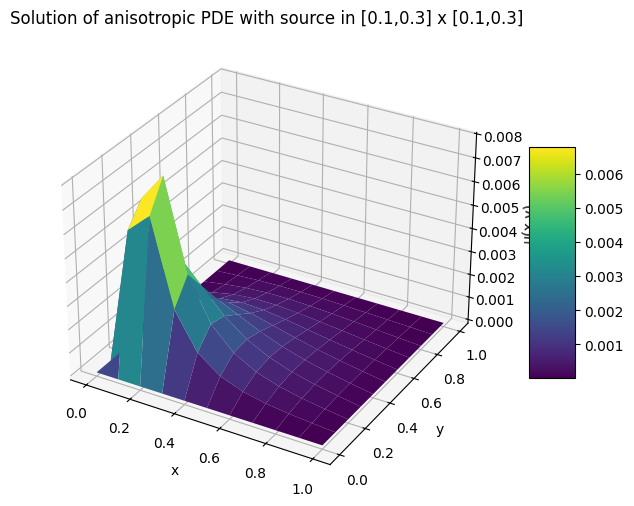

In [35]:
# Sample Parameters
mu_x = 1.0
mu_y = 1.0
h = 0.1
n = int(1./h+1)  # n=11
N = n**2

A = laplacianMatrix(mu_x, mu_y, n)

# Initial guess 
u0 = np.zeros((N,1), dtype=np.float64)

sol = myNewtonSys(laplaceF, fdJacobian, u0, 1e-12, 10, A, n)

# directly reshape
U = sol.reshape(n,n)
X = np.linspace(0,1,n)
Y = np.linspace(0,1,n)
X,Y = np.meshgrid(X,Y)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(X, Y, U, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y)')
ax.set_title('Solution of anisotropic PDE with source in [0.1,0.3] x [0.1,0.3]')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

---
- The output suggests that our of the PDE converged extremely quickly (in essentially zero or one step) because the problem turned out to be linear in $u$ for the chosen setup (the PDE was linear except for the boundary conditions, and the chosen right-hand side did not depend on $u$). When plotting the solution, we see a 3D surface plot with a peak in the designated region shown in Figure 2.

---

### Part (2)(d)(e) Implementation of Conjugate Gradient (CG) Method and Experimentation

In [10]:
def indexFD(i, j, n):
    return i*n + j

def boundaryConditions(n):
    extNodes = []
    for j in range(n):
        extNodes.append(indexFD(j,0,n))
        extNodes.append(indexFD(j,n-1,n))
        extNodes.append(indexFD(0,j,n))
        extNodes.append(indexFD(n-1,j,n))
    extNodes = np.unique(extNodes)
    intNodes = np.setdiff1d(np.arange(n**2), extNodes)
    return intNodes, extNodes

def laplacianMatrix(mu_x, mu_y, n):
    N = n**2
    A = sp.sparse.lil_array((N, N), dtype=np.float64)
    h = 1.0/(n-1)

    for i in range(1,n-1):
        for j in range(1,n-1):
            row = indexFD(i,j,n)
            A[row, row] = 2*(mu_x+mu_y)/h**2
            A[row, indexFD(i-1,j,n)] = -mu_x/h**2
            A[row, indexFD(i+1,j,n)] = -mu_x/h**2
            A[row, indexFD(i,j-1,n)] = -mu_y/h**2
            A[row, indexFD(i,j+1,n)] = -mu_y/h**2

    return A.tocsc()

def source_function(k, n):
    h = 1.0/(n-1)
    i = k // n
    j = k % n
    x = i*h
    y = j*h
    if 0.1 <= x <= 0.3 and 0.1 <= y <= 0.3:
        return 1.0
    else:
        return 0.0

def buildSystem(mu_x, mu_y, n):
    A = laplacianMatrix(mu_x, mu_y, n)
    N = n**2
    f = np.zeros((N,1), dtype=np.float64)
    intNodes, extNodes = boundaryConditions(n)

    for k in intNodes:
        f[k,0] = source_function(k,n)

    A = A.tolil()
    for i in extNodes:
        A[i,:] = 0
        A[i,i] = 1.0
        f[i,0] = 0.0
    A = A.tocsc()
    return A, f

def plotSolution(u, n, title):
    U = u.reshape(n,n)
    X = np.linspace(0,1,n)
    Y = np.linspace(0,1,n)
    X,Y = np.meshgrid(X,Y)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(projection='3d')
    surf = ax.plot_surface(X, Y, U, cmap='viridis')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(x,y)')
    ax.set_title(title)
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

def count_iters(iter_list):
    def callback(rk):
        iter_list[0] += 1
    return callback


---
### Part (2)(d) Solve the problem (from (b) and (c)) using the Conjugate Gradient (CG) $\mu_x = 1$, $\mu_y = 1$, and $h = 0.05$
 
When I solved the system using CG, it took about $53$ iterations to reach the relative tolerance $rtol = 10^{-6}$, since $\mu_x = \mu_y = 1$, the problem is isotropic. An isotropic diffusion problem is usually better conditioned than an anisotropic one, so requiring about 53 iterations is a reasonable result. The solution surface remains symmetric, and the source-induced peak is present where expected. The final solution matches our physical intuition: a smoother and more even spread of the "heat" due to equal diffusion rates in both directions.

---



For (2)(d), mu_x=1, mu_y=1, h=0.05: CG iterations = 53


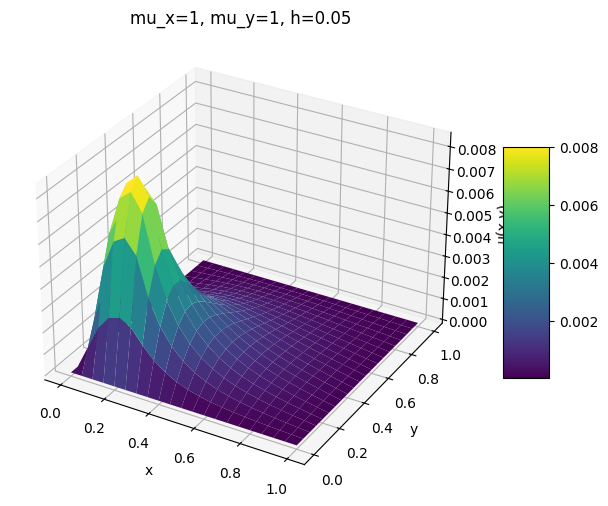

In [34]:
# (2)(d) mu_x=1, mu_y=1, h=0.05
iterations_d = [0]
h_d = 0.05
n_d = int(1/h_d + 1)
A_d, f_d = buildSystem(1.0,1.0,n_d)

u_d, info_d = cg(A_d, f_d, x0=None, rtol=1e-6, callback=count_iters(iterations_d))
print("For (2)(d), mu_x=1, mu_y=1, h=0.05: CG iterations =", iterations_d[0])
plotSolution(u_d, n_d, "mu_x=1, mu_y=1, h=0.05")

---
### Part (2)(e) CG experiment with different anisotropies $(\mu_x = 0.1, \mu_y = 1)$ and $(\mu_x = 0.01, \mu_y = 1)$

- For $\mu_x = 0.1, \mu_y = 1$, CG took about 75 iterations.  
- For $\mu_x = 0.01, \mu_y = 1$, CG took about 80 iterations.  

- By reducing $\mu_x$ while keeping $\mu_y = 1$, its shown as stronger anisotropy. Now diffusion is much weaker in the $x$-direction than in the $y$-direction. Physically, the solution becomes more peaked and localized since it cannot diffuse out as easily along $x$. Numerically, this anisotropy makes the system matrix more ill-conditioned, which leads to CG needing more iterations to achieve the same accuracy. 
- As the anisotropy increases (lower $\mu_x$), we expect the linear system to be harder for CG to solve. Poorer conditioning translates to more CG iterations. The solution surface also shows a more pronounced peak and less spreading in the $x$-direction, consistent with lower $\mu_x$.

---



For (2)(e), mu_x=0.1, mu_y=1: CG iterations = 75


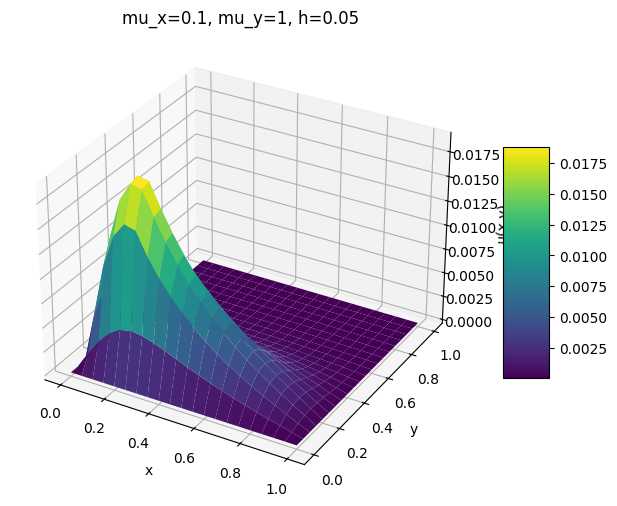

For (2)(e), mu_x=0.01, mu_y=1: CG iterations = 80


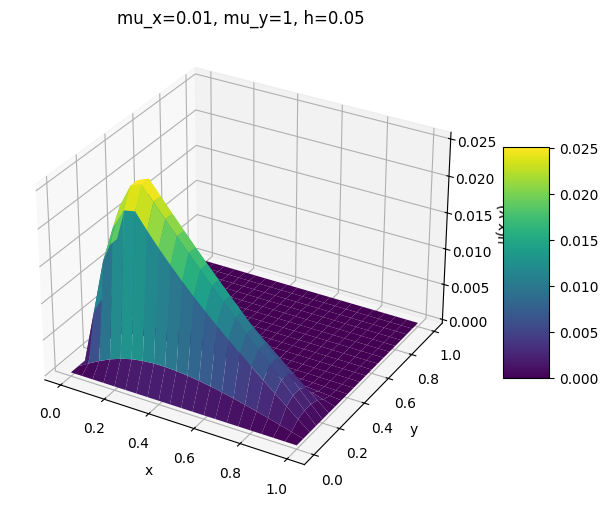

In [36]:
# (2)(e) mu_x=0.1, mu_y=1
iterations_e1 = [0]
A_e1, f_e1 = buildSystem(0.1, 1.0, n_d)
u_e1, info_e1 = cg(A_e1, f_e1, x0=None, rtol=1e-6, callback=count_iters(iterations_e1))
print("For (2)(e), mu_x=0.1, mu_y=1: CG iterations =", iterations_e1[0])
plotSolution(u_e1, n_d, "mu_x=0.1, mu_y=1, h=0.05")

# (2)(e) mu_x=0.01, mu_y=1
iterations_e2 = [0]
A_e2, f_e2 = buildSystem(0.01, 1.0, n_d)
u_e2, info_e2 = cg(A_e2, f_e2, x0=None, rtol=1e-6, callback=count_iters(iterations_e2))
print("For (2)(e), mu_x=0.01, mu_y=1: CG iterations =", iterations_e2[0])
plotSolution(u_e2, n_d, "mu_x=0.01, mu_y=1, h=0.05")

### Conclusion and Reasoning Across (d) and (e):

1. **In part (d):**  
   - With isotropic diffusion ($\mu_x = \mu_y = 1$), we had 53 CG iterations, a moderate number reflecting a relatively well-conditioned problem.

2. **In part (e):**  
   - Reducing $\mu_x$ while holding $\mu_y = 1$ increases anisotropy:
     - At $\mu_x = 0.1$, we got 75 iterations.  
     - At $\mu_x = 0.01$, we got 80 iterations.  
   - This increase in iteration count aligns with the theoretical expectation that anisotropic diffusion problems are harder to solve using iterative methods like CG due to worse conditioning. The more anisotropic the problem, the more challenging it is numerically, and thus the solver requires more iterations.

**Additionally:**  
The shapes of the resulting solution surfaces reflect our physical and mathematical intuition. With lower $\mu_x$, the solution’s peak is higher and more confined because diffusion along $x$ is restricted which is preventing the solution from spreading out as evenly as in the isotropic case.